In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.shape

(7043, 21)

In [4]:
df.columns.tolist()

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [9]:
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

In [10]:
for col in df.select_dtypes(include="object").columns:
    print(f"\n{col}:")
    print(df[col].unique())


customerID:
['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']

gender:
['Female' 'Male']

Partner:
['Yes' 'No']

Dependents:
['No' 'Yes']

PhoneService:
['No' 'Yes']

MultipleLines:
['No phone service' 'No' 'Yes']

InternetService:
['DSL' 'Fiber optic' 'No']

OnlineSecurity:
['No' 'Yes' 'No internet service']

OnlineBackup:
['Yes' 'No' 'No internet service']

DeviceProtection:
['No' 'Yes' 'No internet service']

TechSupport:
['No' 'Yes' 'No internet service']

StreamingTV:
['No' 'Yes' 'No internet service']

StreamingMovies:
['No' 'Yes' 'No internet service']

Contract:
['Month-to-month' 'One year' 'Two year']

PaperlessBilling:
['Yes' 'No']

PaymentMethod:
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']

TotalCharges:
['29.85' '1889.5' '108.15' ... '346.45' '306.6' '6844.5']

Churn:
['No' 'Yes']


In [11]:
df["TotalCharges"].dtype

dtype('O')

In [12]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [13]:
df["TotalCharges"].isnull().sum()

np.int64(11)

In [14]:
df[df["TotalCharges"].isnull()][["customerID", "tenure", "TotalCharges", "Churn"]]

,customerID,tenure,TotalCharges,Churn
488,4472-LVYGI,0,NaN,No
753,3115-CZMZD,0,NaN,No
936,5709-LVOEQ,0,NaN,No
1082,4367-NUYAO,0,NaN,No
1340,1371-DWPAZ,0,NaN,No
3331,7644-OMVMY,0,NaN,No
3826,3213-VVOLG,0,NaN,No
4380,2520-SGTTA,0,NaN,No
5218,2923-ARZLG,0,NaN,No
6670,4075-WKNIU,0,NaN,No


In [15]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)

In [16]:
df.isnull().sum().sum()

np.int64(0)

In [17]:
df.duplicated().sum()

np.int64(0)

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


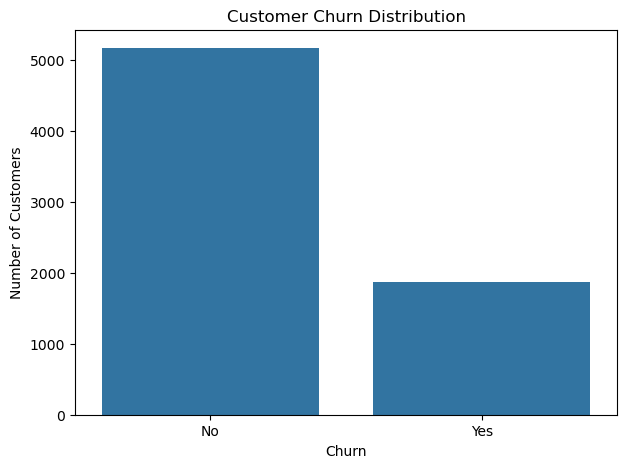

In [19]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

In [20]:
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

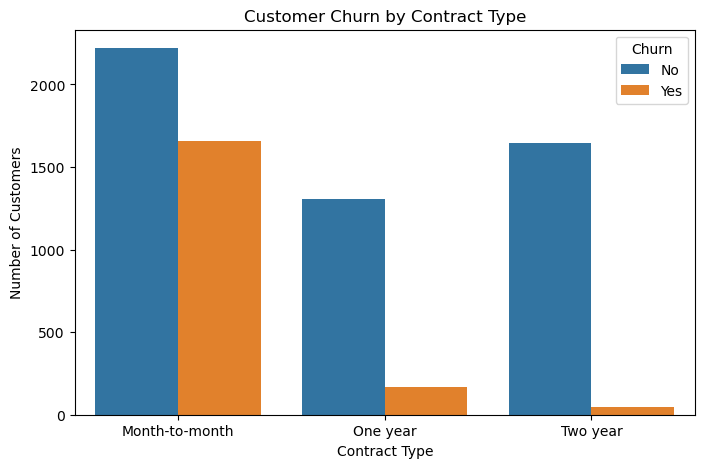

In [21]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="Contract", hue="Churn")

plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.show()

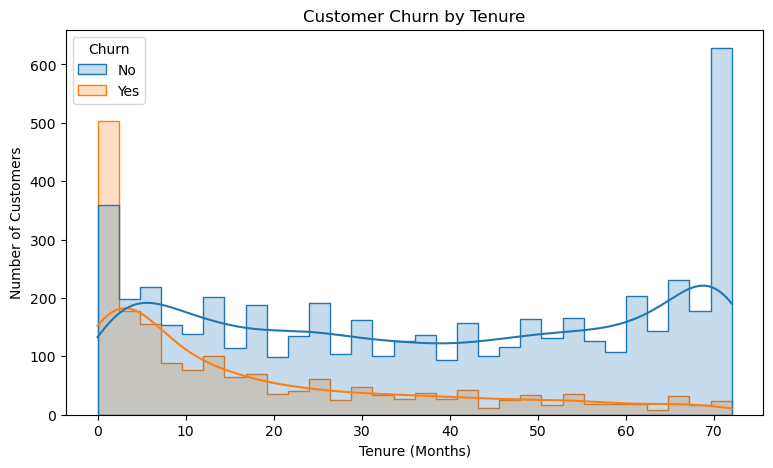

In [22]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="tenure",
    hue="Churn",
    bins=30,
    kde=True,
    element="step"
)

plt.title("Customer Churn by Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.show()

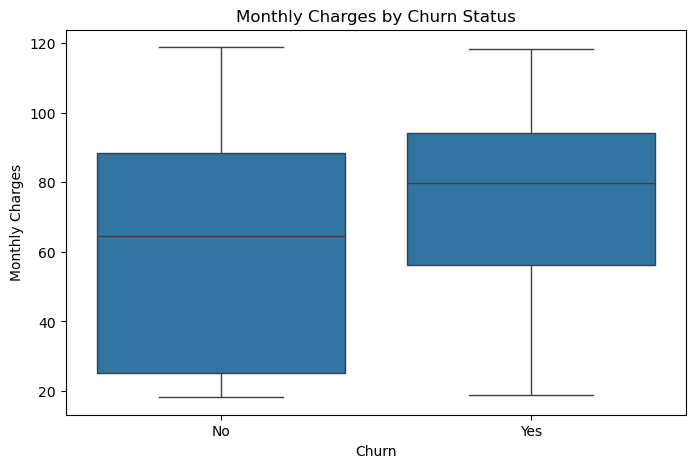

In [23]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="Churn", y="MonthlyCharges")

plt.title("Monthly Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

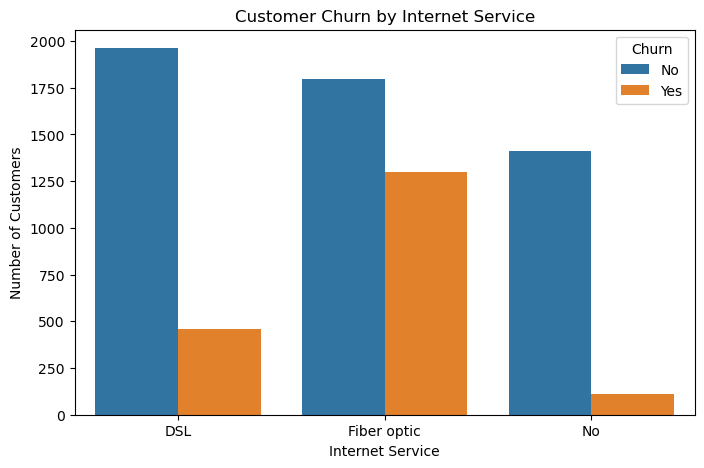

In [24]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="InternetService", hue="Churn")

plt.title("Customer Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")

plt.show()

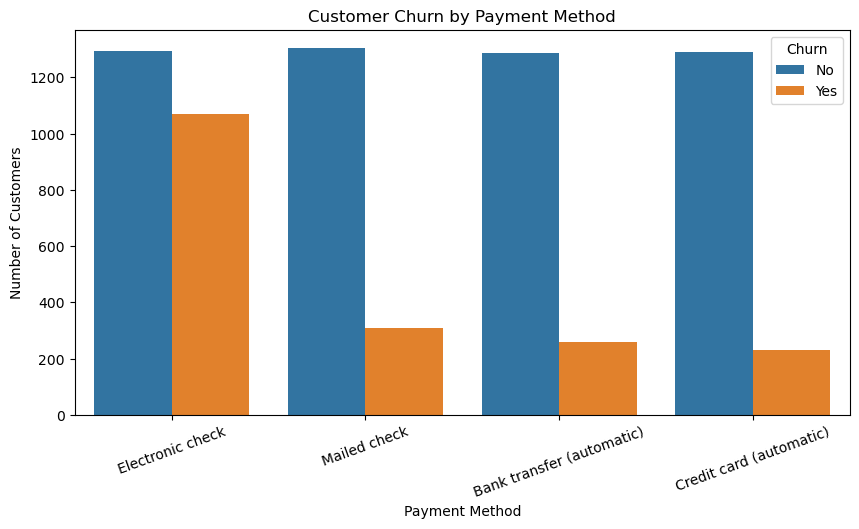

In [25]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="PaymentMethod",
    hue="Churn"
)

plt.title("Customer Churn by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")
plt.xticks(rotation=20)

plt.show()

In [26]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

contract_churn.round(2)

Churn,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.73,11.27
Two year,97.17,2.83


In [27]:
internet_churn = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

internet_churn.round(2)

Churn,No,Yes
InternetService,,
DSL,81.04,18.96
Fiber optic,58.11,41.89
No,92.60,7.40


In [28]:
payment_churn = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

payment_churn.round(2)

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.29,16.71
Credit card (automatic),84.76,15.24
Electronic check,54.71,45.29
Mailed check,80.89,19.11


In [29]:
df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=[0, 12, 24, 48, 72],
    labels=["0-12 months", "13-24 months", "25-48 months", "49-72 months"],
    include_lowest=True
)

In [30]:
tenure_churn = pd.crosstab(
    df["TenureGroup"],
    df["Churn"],
    normalize="index"
) * 100

tenure_churn.round(2)

Churn,No,Yes
TenureGroup,,
0-12 months,52.56,47.44
13-24 months,71.29,28.71
25-48 months,79.61,20.39
49-72 months,90.49,9.51


In [31]:
df.drop("TenureGroup", axis=1, inplace=True)

In [32]:
df.drop("customerID", axis=1, inplace=True)

In [33]:
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

In [34]:
df["Churn"].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

In [35]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [36]:
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (7043, 19)
Target shape: (7043,)


In [37]:
categorical_cols = X.select_dtypes(include="object").columns
numerical_cols = X.select_dtypes(exclude="object").columns

print("Categorical columns:")
print(categorical_cols.tolist())

print("\nNumerical columns:")
print(numerical_cols.tolist())

Categorical columns:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Numerical columns:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [39]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (5634, 19)
Testing data: (1409, 19)


In [40]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

In [41]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_cols
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_cols
        )
    ]
)

In [42]:
from sklearn.linear_model import LogisticRegression

In [43]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000))
    ]
)

In [44]:
logistic_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [45]:
y_pred = logistic_model.predict(X_test)

In [46]:
y_prob = logistic_model.predict_proba(X_test)[:, 1]

In [47]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.8055


In [48]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=["Stayed", "Churned"]
))

              precision    recall  f1-score   support

      Stayed       0.85      0.89      0.87      1035
     Churned       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



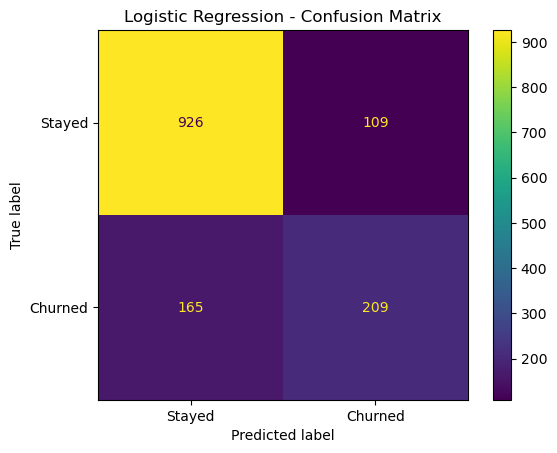

In [49]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Stayed", "Churned"]
)

disp.plot()
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [50]:
y_prob

array([0.04591993, 0.68371345, 0.05893985, ..., 0.15442215, 0.00428645,
       0.00628801], shape=(1409,))

In [51]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test, y_prob)

print(f"ROC-AUC: {roc_auc:.4f}")

ROC-AUC: 0.8421


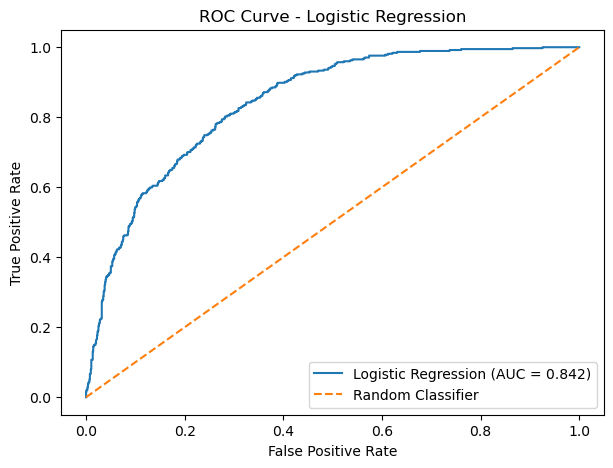

In [52]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

In [53]:
logistic_results = {
    "Model": "Logistic Regression",
    "Accuracy": accuracy,
    "ROC-AUC": roc_auc
}

logistic_results

{'Model': 'Logistic Regression',
 'Accuracy': 0.8055358410220014,
 'ROC-AUC': 0.8421349040274871}

In [54]:
from sklearn.tree import DecisionTreeClassifier

In [55]:
decision_tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", DecisionTreeClassifier(
            max_depth=5,
            random_state=42
        ))
    ]
)

In [56]:
decision_tree_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [57]:
dt_pred = decision_tree_model.predict(X_test)
dt_prob = decision_tree_model.predict_proba(X_test)[:, 1]

In [58]:
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

dt_accuracy = accuracy_score(y_test, dt_pred)
dt_roc_auc = roc_auc_score(y_test, dt_prob)

print(f"Decision Tree Accuracy: {dt_accuracy:.4f}")
print(f"Decision Tree ROC-AUC: {dt_roc_auc:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test,
    dt_pred,
    target_names=["Stayed", "Churned"]
))

Decision Tree Accuracy: 0.7984
Decision Tree ROC-AUC: 0.8297

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.85      0.88      0.87      1035
     Churned       0.63      0.57      0.60       374

    accuracy                           0.80      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409



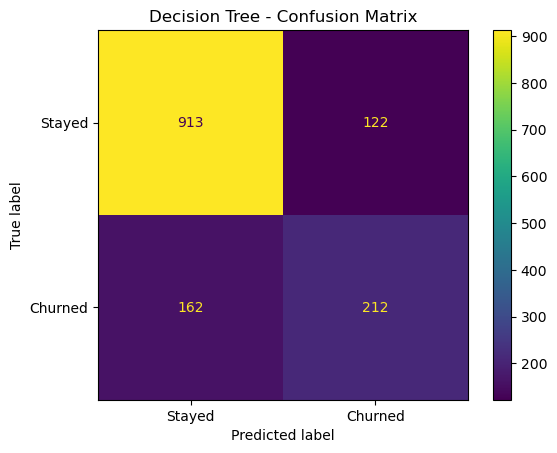

In [59]:
cm_dt = confusion_matrix(y_test, dt_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_dt,
    display_labels=["Stayed", "Churned"]
)

disp.plot()
plt.title("Decision Tree - Confusion Matrix")
plt.show()

In [60]:
from sklearn.ensemble import RandomForestClassifier

In [61]:
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=300,
            max_depth=8,
            min_samples_split=5,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

In [62]:
random_forest_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [63]:
rf_pred = random_forest_model.predict(X_test)
rf_prob = random_forest_model.predict_proba(X_test)[:, 1]

In [64]:
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_roc_auc = roc_auc_score(y_test, rf_prob)

print(f"Random Forest Accuracy: {rf_accuracy:.4f}")
print(f"Random Forest ROC-AUC: {rf_roc_auc:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test,
    rf_pred,
    target_names=["Stayed", "Churned"]
))

Random Forest Accuracy: 0.8077
Random Forest ROC-AUC: 0.8422

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.84      0.91      0.87      1035
     Churned       0.68      0.52      0.59       374

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409



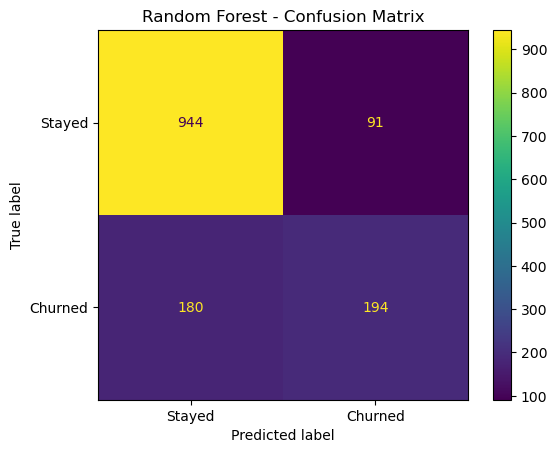

In [65]:
cm_rf = confusion_matrix(y_test, rf_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["Stayed", "Churned"]
)

disp.plot()
plt.title("Random Forest - Confusion Matrix")
plt.show()

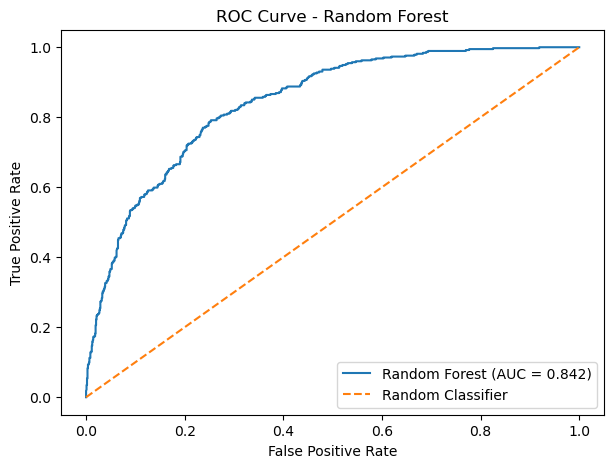

In [66]:
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)

plt.figure(figsize=(7, 5))

plt.plot(
    rf_fpr,
    rf_tpr,
    label=f"Random Forest (AUC = {rf_roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.show()

In [67]:
from sklearn.model_selection import GridSearchCV

In [68]:
logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000))
    ]
)

In [69]:
param_grid = {
    "classifier__C": [0.01, 0.1, 1, 10, 100]
}

In [71]:
grid_search = GridSearchCV(
    logistic_pipeline,
    param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

,estimator,Pipeline(step..._iter=1000))])
,param_grid,"{'classifier__C': [0.01, 0.1, ...]}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [72]:
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation ROC-AUC:", grid_search.best_score_)

Best Parameters: {'classifier__C': 10}
Best Cross-Validation ROC-AUC: 0.8459390177818094


In [73]:
tuned_logistic = grid_search.best_estimator_

tuned_pred = tuned_logistic.predict(X_test)
tuned_prob = tuned_logistic.predict_proba(X_test)[:, 1]

tuned_accuracy = accuracy_score(y_test, tuned_pred)
tuned_roc_auc = roc_auc_score(y_test, tuned_prob)

print(f"Tuned Logistic Regression Accuracy: {tuned_accuracy:.4f}")
print(f"Tuned Logistic Regression ROC-AUC: {tuned_roc_auc:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test,
    tuned_pred,
    target_names=["Stayed", "Churned"]
))

Tuned Logistic Regression Accuracy: 0.8048
Tuned Logistic Regression ROC-AUC: 0.8412

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.85      0.89      0.87      1035
     Churned       0.66      0.56      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409



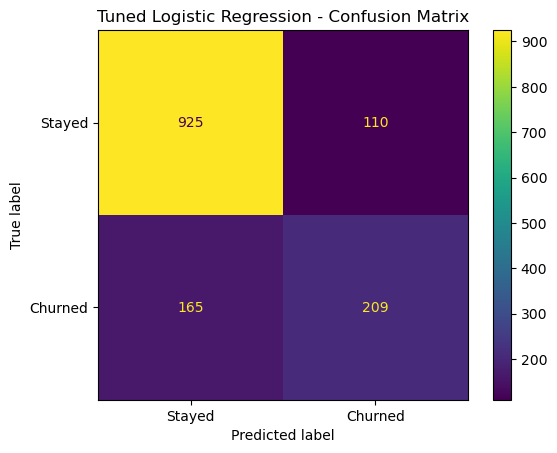

In [74]:
cm_tuned = confusion_matrix(y_test, tuned_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_tuned,
    display_labels=["Stayed", "Churned"]
)

disp.plot()
plt.title("Tuned Logistic Regression - Confusion Matrix")
plt.show()

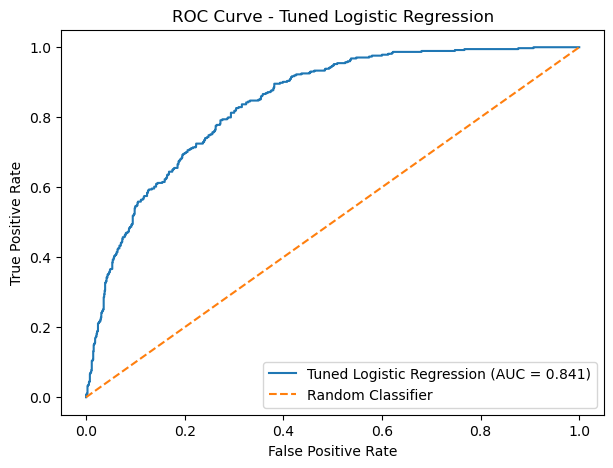

In [75]:
tuned_fpr, tuned_tpr, _ = roc_curve(y_test, tuned_prob)

plt.figure(figsize=(7, 5))

plt.plot(
    tuned_fpr,
    tuned_tpr,
    label=f"Tuned Logistic Regression (AUC = {tuned_roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Tuned Logistic Regression")
plt.legend()
plt.show()

In [76]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Tuned Logistic Regression"
    ],
    "Accuracy": [
        accuracy,
        dt_accuracy,
        rf_accuracy,
        tuned_accuracy
    ],
    "Churn Recall": [
        0.56,
        0.57,
        0.52,
        0.56
    ],
    "Churn F1": [
        0.60,
        0.60,
        0.59,
        0.60
    ],
    "ROC-AUC": [
        roc_auc,
        dt_roc_auc,
        rf_roc_auc,
        tuned_roc_auc
    ]
})

results.round(4)

,Model,Accuracy,Churn Recall,Churn F1,ROC-AUC
0,Logistic Regression,0.8055,0.56,0.60,0.8421
1,Decision Tree,0.7984,0.57,0.60,0.8297
2,Random Forest,0.8077,0.52,0.59,0.8422
3,Tuned Logistic Regression,0.8048,0.56,0.60,0.8412


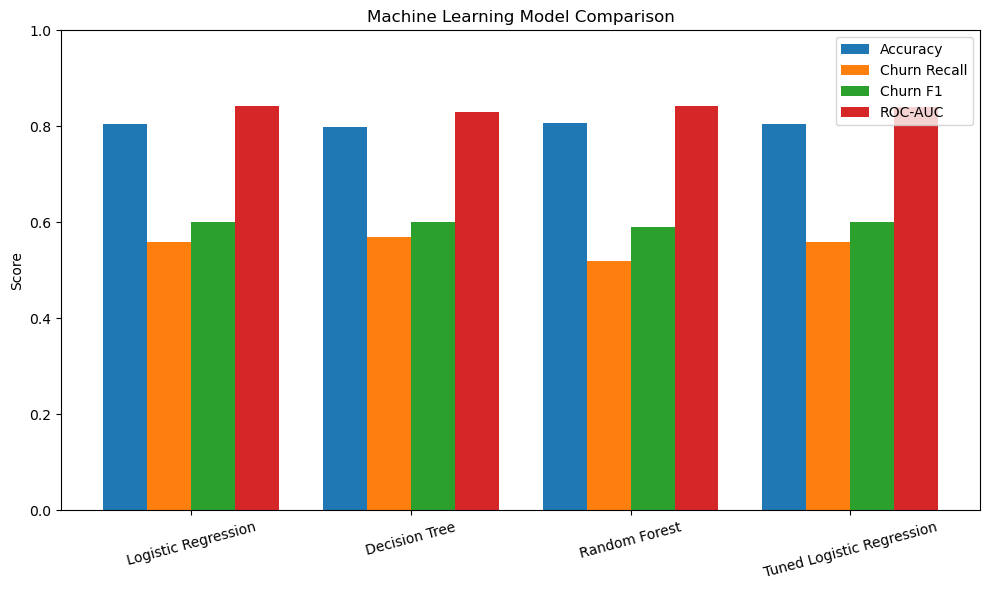

In [77]:
plt.figure(figsize=(10, 6))

x = np.arange(len(results["Model"]))
width = 0.2

plt.bar(x - 1.5*width, results["Accuracy"], width, label="Accuracy")
plt.bar(x - 0.5*width, results["Churn Recall"], width, label="Churn Recall")
plt.bar(x + 0.5*width, results["Churn F1"], width, label="Churn F1")
plt.bar(x + 1.5*width, results["ROC-AUC"], width, label="ROC-AUC")

plt.xticks(x, results["Model"], rotation=15)
plt.ylabel("Score")
plt.title("Machine Learning Model Comparison")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

In [78]:
final_model = logistic_model

In [79]:
print("Final Model: Logistic Regression")
print(f"Accuracy: {accuracy:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")

Final Model: Logistic Regression
Accuracy: 0.8055
ROC-AUC: 0.8421


In [80]:
feature_names = final_model.named_steps["preprocessor"].get_feature_names_out()

len(feature_names)

45

In [81]:
coefficients = final_model.named_steps["classifier"].coef_[0]

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

feature_importance["Absolute_Coefficient"] = (
    feature_importance["Coefficient"].abs()
)

feature_importance = feature_importance.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

feature_importance.head(15)

,Feature,Coefficient,Absolute_Coefficient
1,num__tenure,-1.257539,1.257539
38,cat__Contract_Two year,-0.776594,0.776594
15,cat__InternetService_DSL,-0.648646,0.648646
16,cat__InternetService_Fiber optic,0.634195,0.634195
2,num__MonthlyCharges,-0.591863,0.591863
36,cat__Contract_Month-to-month,0.582883,0.582883
3,num__TotalCharges,0.536253,0.536253
39,cat__PaperlessBilling_No,-0.343227,0.343227
22,cat__OnlineBackup_No internet service,-0.300104,0.300104
17,cat__InternetService_No,-0.300104,0.300104


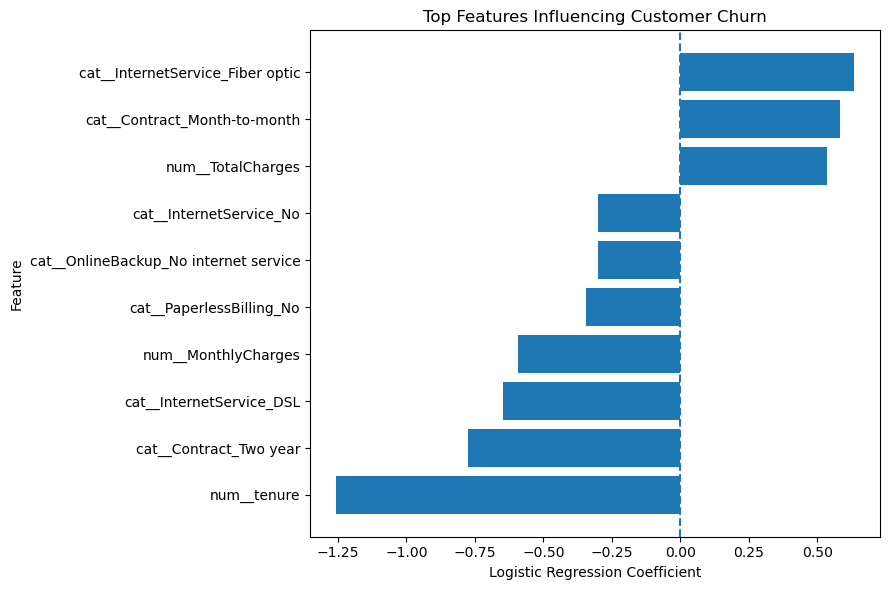

In [82]:
top_features = feature_importance.head(10).sort_values("Coefficient")

plt.figure(figsize=(9, 6))

plt.barh(
    top_features["Feature"],
    top_features["Coefficient"]
)

plt.axvline(0, linestyle="--")

plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.title("Top Features Influencing Customer Churn")

plt.tight_layout()
plt.show()


In [83]:
print("Top features associated with higher churn:")
display(
    feature_importance
    .sort_values("Coefficient", ascending=False)
    .head(10)[["Feature", "Coefficient"]]
)

Top features associated with higher churn:


,Feature,Coefficient
16,cat__InternetService_Fiber optic,0.634195
36,cat__Contract_Month-to-month,0.582883
3,num__TotalCharges,0.536253
35,cat__StreamingMovies_Yes,0.200938
32,cat__StreamingTV_Yes,0.200481
43,cat__PaymentMethod_Electronic check,0.197867
18,cat__OnlineSecurity_No,0.156279
27,cat__TechSupport_No,0.131503
14,cat__MultipleLines_Yes,0.104649
0,num__SeniorCitizen,0.053449


In [84]:
print("Top features associated with lower churn:")
display(
    feature_importance
    .sort_values("Coefficient", ascending=True)
    .head(10)[["Feature", "Coefficient"]]
)

Top features associated with lower churn:


,Feature,Coefficient
1,num__tenure,-1.257539
38,cat__Contract_Two year,-0.776594
15,cat__InternetService_DSL,-0.648646
2,num__MonthlyCharges,-0.591863
39,cat__PaperlessBilling_No,-0.343227
19,cat__OnlineSecurity_No internet service,-0.300104
34,cat__StreamingMovies_No internet service,-0.300104
31,cat__StreamingTV_No internet service,-0.300104
22,cat__OnlineBackup_No internet service,-0.300104
17,cat__InternetService_No,-0.300104


In [85]:
import joblib

joblib.dump(
    final_model,
    "customer_churn_model.pkl"
)

print("Model saved successfully!")

Model saved successfully!


In [86]:
import ipywidgets as widgets
from IPython.display import display

print("UI libraries are ready!")

UI libraries are ready!


In [87]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# Create input widgets
gender = widgets.Dropdown(
    options=df["gender"].unique().tolist(),
    description="Gender:"
)

senior_citizen = widgets.Dropdown(
    options=[0, 1],
    description="Senior:"
)

partner = widgets.Dropdown(
    options=df["Partner"].unique().tolist(),
    description="Partner:"
)

dependents = widgets.Dropdown(
    options=df["Dependents"].unique().tolist(),
    description="Dependents:"
)

tenure = widgets.IntSlider(
    value=12,
    min=0,
    max=72,
    step=1,
    description="Tenure:"
)

phone_service = widgets.Dropdown(
    options=df["PhoneService"].unique().tolist(),
    description="Phone:"
)

multiple_lines = widgets.Dropdown(
    options=df["MultipleLines"].unique().tolist(),
    description="Multiple:"
)

internet_service = widgets.Dropdown(
    options=df["InternetService"].unique().tolist(),
    description="Internet:"
)

online_security = widgets.Dropdown(
    options=df["OnlineSecurity"].unique().tolist(),
    description="Security:"
)

online_backup = widgets.Dropdown(
    options=df["OnlineBackup"].unique().tolist(),
    description="Backup:"
)

device_protection = widgets.Dropdown(
    options=df["DeviceProtection"].unique().tolist(),
    description="Protection:"
)

tech_support = widgets.Dropdown(
    options=df["TechSupport"].unique().tolist(),
    description="Support:"
)

streaming_tv = widgets.Dropdown(
    options=df["StreamingTV"].unique().tolist(),
    description="TV:"
)

streaming_movies = widgets.Dropdown(
    options=df["StreamingMovies"].unique().tolist(),
    description="Movies:"
)

contract = widgets.Dropdown(
    options=df["Contract"].unique().tolist(),
    description="Contract:"
)

paperless_billing = widgets.Dropdown(
    options=df["PaperlessBilling"].unique().tolist(),
    description="Paperless:"
)

payment_method = widgets.Dropdown(
    options=df["PaymentMethod"].unique().tolist(),
    description="Payment:"
)

monthly_charges = widgets.FloatText(
    value=70.0,
    description="Monthly:"
)

total_charges = widgets.FloatText(
    value=840.0,
    description="Total:"
)

In [88]:
predict_button = widgets.Button(
    description="Predict Churn",
    button_style="primary",
    icon="check"
)

output = widgets.Output()

In [89]:
def predict_churn(button):
    with output:
        clear_output()

        customer_data = pd.DataFrame([{
            "gender": gender.value,
            "SeniorCitizen": senior_citizen.value,
            "Partner": partner.value,
            "Dependents": dependents.value,
            "tenure": tenure.value,
            "PhoneService": phone_service.value,
            "MultipleLines": multiple_lines.value,
            "InternetService": internet_service.value,
            "OnlineSecurity": online_security.value,
            "OnlineBackup": online_backup.value,
            "DeviceProtection": device_protection.value,
            "TechSupport": tech_support.value,
            "StreamingTV": streaming_tv.value,
            "StreamingMovies": streaming_movies.value,
            "Contract": contract.value,
            "PaperlessBilling": paperless_billing.value,
            "PaymentMethod": payment_method.value,
            "MonthlyCharges": monthly_charges.value,
            "TotalCharges": total_charges.value
        }])

        prediction = final_model.predict(customer_data)[0]
        probability = final_model.predict_proba(customer_data)[0][1]

        print("====================================")
        print("       CUSTOMER CHURN PREDICTION")
        print("====================================")

        if prediction == 1:
            print("⚠️  HIGH CHURN RISK")
        else:
            print("✅  LOW CHURN RISK")

        print(f"\nChurn Probability: {probability:.2%}")
        print("====================================")

In [90]:
predict_button.on_click(predict_churn)

In [91]:
ui = widgets.VBox([
    widgets.HTML("<h2>Customer Churn Predictor</h2>"),
    
    widgets.HTML("<h3>Customer Information</h3>"),
    gender,
    senior_citizen,
    partner,
    dependents,
    tenure,
    
    widgets.HTML("<h3>Services</h3>"),
    phone_service,
    multiple_lines,
    internet_service,
    online_security,
    online_backup,
    device_protection,
    tech_support,
    streaming_tv,
    streaming_movies,
    
    widgets.HTML("<h3>Account Information</h3>"),
    contract,
    paperless_billing,
    payment_method,
    monthly_charges,
    total_charges,
    
    predict_button,
    output
])

display(ui)